# Question 1 - Stock Price Forecasting using LSTM

## Dataset: INTC (Intel Corporation)

Dataset ini berisi data historis saham Intel Corporation (INTC) dari Yahoo Finance mulai 17 Maret 1980 hingga 1 April 2020.

Sesuai instruksi soal, hanya kolom berikut yang digunakan:

- Date
- Close

Tujuan penelitian adalah memprediksi harga penutupan saham pada hari berikutnya menggunakan arsitektur Long Short-Term Memory (LSTM).

Metode forecasting yang digunakan adalah:

- Window Size = 5
- Horizon = 1

Artinya model menggunakan harga penutupan 5 hari sebelumnya sebagai input untuk memprediksi harga penutupan pada hari berikutnya.

Sebelum proses pelatihan model, data dipisahkan menjadi data training dan data testing, dengan data testing mencakup satu tahun terakhir sesuai ketentuan soal. Selanjutnya dilakukan normalisasi menggunakan MinMaxScaler dan pembentukan data time series menggunakan teknik sliding window sebelum digunakan sebagai input pada model LSTM.

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# EDA

Load Dataset

In [2]:
df = pd.read_csv("INTC.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-03-17,0.325521,0.330729,0.325521,0.325521,0.204750,10924800
1,1980-03-18,0.325521,0.328125,0.322917,0.322917,0.203112,17068800
2,1980-03-19,0.330729,0.335938,0.330729,0.330729,0.208026,18508800
3,1980-03-20,0.330729,0.334635,0.329427,0.329427,0.207207,11174400
4,1980-03-21,0.322917,0.322917,0.317708,0.317708,0.199836,12172800


Dataset Information

In [3]:
print("Dataset Shape:", df.shape) 
df.info()

Dataset Shape: (10098, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10098 entries, 0 to 10097
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10098 non-null  object 
 1   Open       10098 non-null  float64
 2   High       10098 non-null  float64
 3   Low        10098 non-null  float64
 4   Close      10098 non-null  float64
 5   Adj Close  10098 non-null  float64
 6   Volume     10098 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 552.4+ KB


Dataset INTC terdiri dari 10.098 observasi harian saham Intel Corporation dari 17 Maret 1980 hingga 1 April 2020.

Dataset awal memiliki 7 fitur yaitu:

Date
Open
High
Low
Close
Adj Close
Volume

Sesuai instruksi soal, hanya fitur Date dan Close yang digunakan untuk membangun model forecasting.

Berdasarkan hasil pemeriksaan struktur data, seluruh kolom memiliki 10.098 nilai valid (non-null), sehingga tidak terdapat missing value yang perlu ditangani pada tahap preprocessing.

Missing Value Analysis

In [4]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Tidak ditemukan missing value pada dataset sehingga tidak diperlukan proses data cleaning atau imputasi.

Selecting Required Features

In [5]:
df = df[['Date', 'Close']] 
df['Date'] = pd.to_datetime(df['Date']) 
df.head()

,Date,Close
0,1980-03-17,0.325521
1,1980-03-18,0.322917
2,1980-03-19,0.330729
3,1980-03-20,0.329427
4,1980-03-21,0.317708


Descriptive Statistics

In [6]:
df['Close'].describe()


count    10098.000000
mean        17.771604
std         16.108504
min          0.216146
25%          1.132812
50%         19.255000
75%         27.307499
max         74.875000
Name: Close, dtype: float64

Beberapa temuan penting dari statistik deskriptif:

Harga penutupan minimum adalah 0.22 USD sedangkan harga maksimum mencapai 74.88 USD.
Rentang harga yang sangat besar menunjukkan adanya perubahan nilai saham yang signifikan selama lebih dari 40 tahun periode pengamatan.
Nilai standar deviasi sebesar 16.11 menunjukkan volatilitas harga yang cukup tinggi.
Median (19.26 USD) lebih tinggi dibanding kuartil pertama (1.13 USD), menunjukkan distribusi data tidak simetris dan dipengaruhi oleh tren pertumbuhan jangka panjang.
Perbedaan skala yang besar antara nilai minimum dan maksimum menjadi alasan penggunaan MinMaxScaler sebelum proses training LSTM.

Berdasarkan temuan tersebut, normalisasi data menjadi langkah penting untuk menjaga stabilitas proses optimasi model.

Closing Price Trend

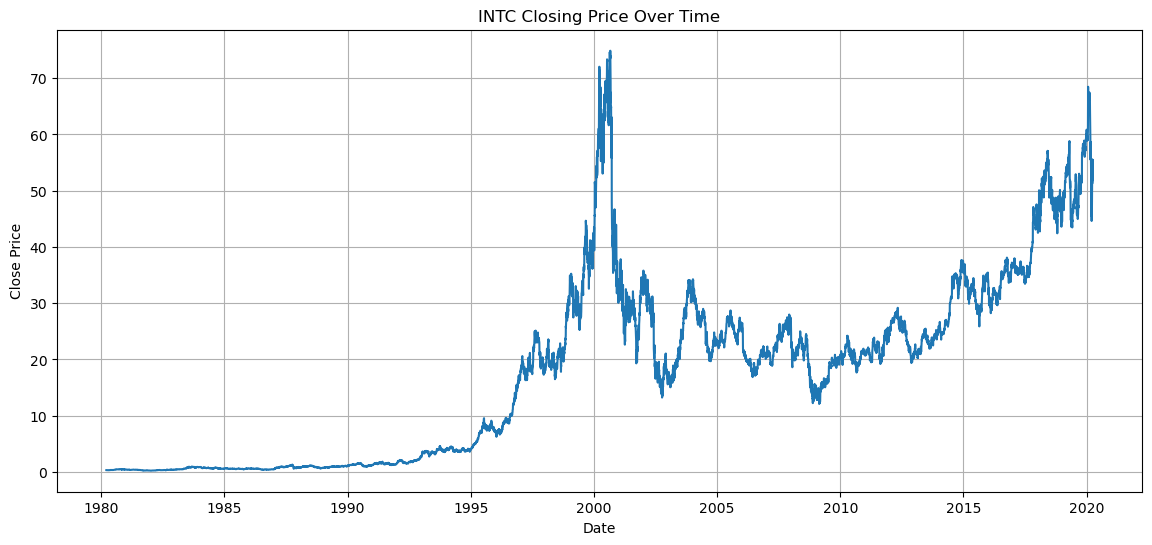

In [7]:
plt.figure(figsize=(14,6)) 
plt.plot(df['Date'], df['Close']) 
plt.title('INTC Closing Price Over Time') 
plt.xlabel('Date') 
plt.ylabel('Close Price') 
plt.grid(True) 
plt.show()

### Insight

Grafik menunjukkan tren kenaikan harga saham Intel yang sangat kuat dalam jangka panjang, dari sekitar 0.3 USD pada tahun 1980 menjadi lebih dari 45 USD pada tahun 2020.

Selain tren naik jangka panjang, terdapat beberapa periode perubahan harga yang sangat signifikan, terutama pada periode dot-com bubble sekitar tahun 1999–2001 ketika harga saham meningkat hingga lebih dari 70 USD sebelum mengalami penurunan tajam.

Pola ini menunjukkan bahwa data memiliki karakteristik time series yang kompleks dengan kombinasi tren jangka panjang dan fluktuasi yang cukup besar.

Karena nilai historis sebelumnya berpengaruh terhadap nilai di masa depan, pendekatan time series forecasting menggunakan LSTM dipilih untuk menangkap dependensi temporal tersebut.

Distribution Analysis

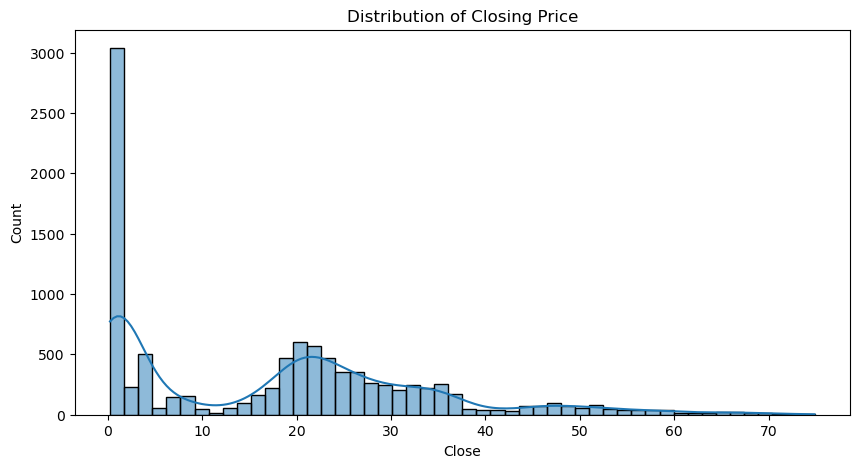

In [8]:
plt.figure(figsize=(10,5)) 
sns.histplot(df['Close'], bins=50, kde=True) 
plt.title('Distribution of Closing Price') 
plt.show()

### Insight

Distribusi harga saham INTC tidak mengikuti distribusi normal dan menunjukkan karakteristik right-skewed.

Sebagian besar data terkonsentrasi pada harga rendah hingga menengah, sementara sejumlah observasi berada pada rentang harga yang jauh lebih tinggi akibat pertumbuhan perusahaan dalam jangka panjang.

Distribusi yang tidak simetris ini menunjukkan bahwa harga saham berada pada beberapa fase pertumbuhan yang berbeda selama periode pengamatan.

Selain itu, rentang harga yang cukup lebar menyebabkan perbedaan skala yang signifikan sehingga normalisasi menggunakan MinMaxScaler diperlukan sebelum data digunakan oleh model LSTM.

Moving Average Analysis

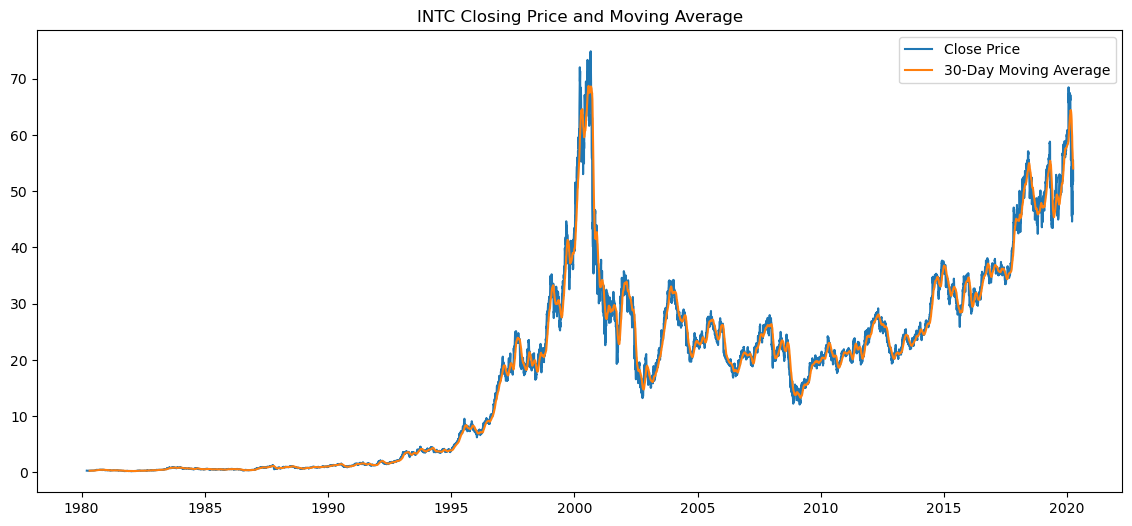

In [9]:
df['MA30'] = df['Close'].rolling(window=30).mean() 
plt.figure(figsize=(14,6)) 
plt.plot(df['Date'], df['Close'], label='Close Price') 
plt.plot(df['Date'], df['MA30'], label='30-Day Moving Average') 
plt.legend() 
plt.title('INTC Closing Price and Moving Average') 
plt.show()

### Insight

Kurva Moving Average 30 hari mengikuti pola harga penutupan aktual dengan baik dan berhasil mengurangi fluktuasi harian yang bersifat noise.

Terlihat bahwa tren jangka panjang mendominasi pola pergerakan saham Intel, meskipun terdapat beberapa periode perubahan harga yang sangat cepat.

Temuan ini menunjukkan bahwa informasi historis memiliki pengaruh yang kuat terhadap pergerakan harga berikutnya sehingga model forecasting perlu mampu mempelajari pola temporal jangka panjang secara efektif.

Volatility Analysis

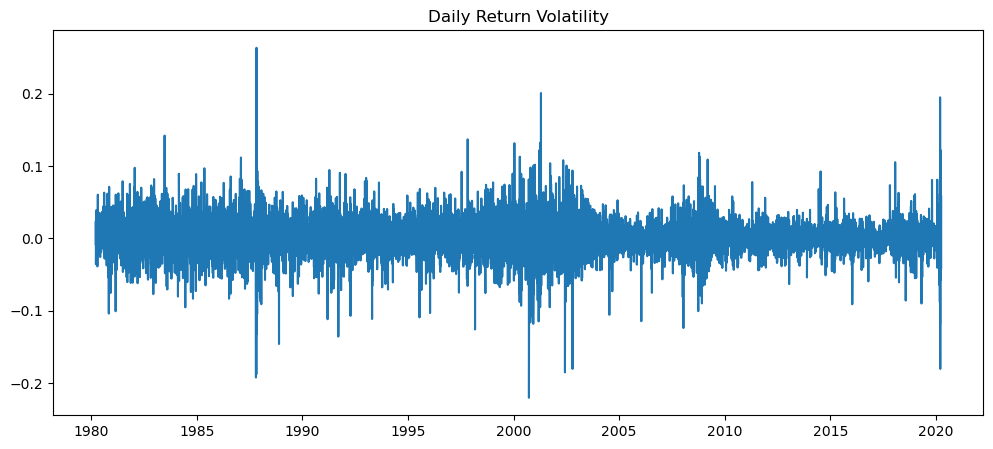

In [10]:
returns = df['Close'].pct_change() 
plt.figure(figsize=(12,5)) 
plt.plot(df['Date'], returns) 
plt.title('Daily Return Volatility') 
plt.show()

### Insight

Grafik return harian menunjukkan bahwa sebagian besar perubahan harga berada di sekitar nol, namun terdapat beberapa lonjakan ekstrem yang menunjukkan periode volatilitas tinggi.

Lonjakan volatilitas terlihat sangat jelas pada periode dot-com bubble sekitar tahun 2000 serta beberapa periode krisis pasar lainnya.

Kondisi ini menunjukkan bahwa harga saham INTC mengalami perubahan yang sangat dinamis pada beberapa periode tertentu sehingga model forecasting perlu memiliki kemampuan generalisasi yang baik untuk menghindari overfitting.

Oleh karena itu, pada model enhanced akan digunakan pendekatan arsitektur yang lebih mampu menangkap pola temporal jangka panjang dibandingkan model baseline.

<Figure size 1000x500 with 0 Axes>

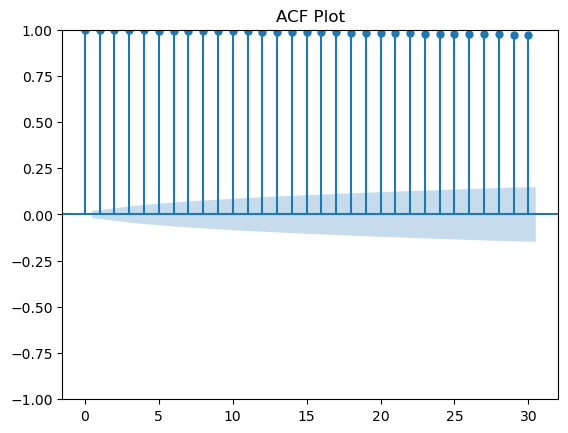

In [11]:
# ACF
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    df['Close'],
    lags=30
)

plt.title('ACF Plot')
plt.show()

### ACF Analysis Insight

Autocorrelation Function (ACF) digunakan untuk mengukur hubungan antara suatu observasi dengan observasi pada beberapa periode sebelumnya.

Berdasarkan grafik ACF, terlihat bahwa hampir seluruh lag hingga lag ke-30 memiliki nilai autokorelasi yang sangat tinggi dan berada jauh di atas batas confidence interval. Nilai autokorelasi juga menurun secara sangat lambat dan tetap mendekati 1 pada sebagian besar lag.

Temuan ini menunjukkan bahwa harga saham INTC memiliki ketergantungan yang sangat kuat terhadap nilai historis sebelumnya serta mengandung tren jangka panjang yang signifikan. Pola tersebut merupakan karakteristik umum dari data time series yang bersifat non-stationary.

Hasil analisis ACF menunjukkan bahwa informasi masa lalu memiliki pengaruh yang kuat terhadap nilai saat ini sehingga pendekatan forecasting berbasis Long Short-Term Memory (LSTM) sangat sesuai digunakan untuk memodelkan data saham INTC.

<Figure size 1000x500 with 0 Axes>

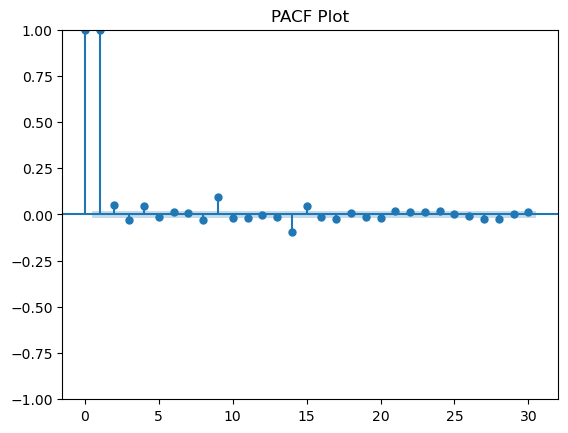

In [12]:
# PACF
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))

plot_pacf(
    df['Close'],
    lags=30
)

plt.title('PACF Plot')
plt.show()

### PACF Analysis Insight

Partial Autocorrelation Function (PACF) digunakan untuk mengukur pengaruh langsung suatu lag terhadap nilai saat ini setelah menghilangkan pengaruh lag lainnya.

Berdasarkan grafik PACF, terlihat bahwa lag pertama memiliki nilai yang sangat tinggi dan signifikan. Setelah lag pertama, sebagian besar nilai PACF berada di sekitar nol dan berada dalam batas confidence interval.

Pola ini menunjukkan bahwa hubungan temporal terkuat berasal dari observasi yang berdekatan dalam waktu, terutama harga saham pada periode sebelumnya. Dengan kata lain, harga saham hari ini memiliki ketergantungan langsung yang sangat kuat terhadap harga saham pada hari sebelumnya.

Selain itu, tidak terlihat banyak lag signifikan setelah lag pertama, yang menunjukkan bahwa sebagian besar informasi prediktif telah terkandung pada beberapa observasi awal. Temuan ini mendukung penggunaan window size sebesar 5 yang digunakan dalam penelitian.

### ACF-PACF Conclusion

Berdasarkan analisis ACF dan PACF, data saham INTC menunjukkan adanya autokorelasi yang sangat kuat dan ketergantungan temporal yang signifikan terhadap nilai historis sebelumnya.

Nilai autokorelasi yang tinggi pada ACF mengindikasikan adanya tren jangka panjang yang kuat, sedangkan PACF menunjukkan bahwa pengaruh langsung terbesar berasal dari lag pertama. Karakteristik tersebut menunjukkan bahwa harga saham saat ini sangat dipengaruhi oleh harga saham pada periode sebelumnya.

Temuan ini mendukung penggunaan model Long Short-Term Memory (LSTM) karena model tersebut dirancang untuk mempelajari hubungan temporal dan memanfaatkan informasi historis dalam melakukan forecasting harga saham.

Selain itu, hasil ACF dan PACF juga menunjukkan bahwa pemisahan data secara kronologis (train-test split berdasarkan waktu) merupakan pendekatan yang tepat karena observasi dalam data memiliki keterkaitan yang kuat antar periode.

In [13]:
print("Start Date :", df['Date'].min())
print("End Date   :", df['Date'].max())

growth = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) /
          df['Close'].iloc[0]) * 100

print(f"Growth Percentage : {growth:.2f}%")

Start Date : 1980-03-17 00:00:00
End Date   : 2020-04-01 00:00:00
Growth Percentage : 15837.54%


### Trend Analysis Insight

Output:

Start Date : 1980-03-17

End Date : 2020-04-01

Growth Percentage : 15837.54%

Berdasarkan hasil analisis, harga saham INTC mengalami kenaikan sebesar 15837.54% selama periode pengamatan dari Maret 1980 hingga April 2020.

Peningkatan yang sangat besar ini menunjukkan bahwa data memiliki upward trend yang sangat kuat dalam jangka panjang. Selain itu, rata-rata harga saham berubah secara konsisten sepanjang periode observasi sehingga data dapat dikategorikan sebagai non-stationary time series.

Karena karakteristik utama data adalah pola tren jangka panjang dan ketergantungan terhadap nilai historis sebelumnya, pendekatan berbasis Long Short-Term Memory (LSTM) dipilih karena mampu mempelajari hubungan temporal antar observasi pada data time series.

Temuan ini juga menjadi alasan dilakukannya normalisasi menggunakan MinMaxScaler karena rentang harga saham berubah secara signifikan dari awal hingga akhir periode pengamatan.

## EDA Conclusion

Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh beberapa temuan utama:

1. Dataset terdiri dari 10.098 data historis saham Intel Corporation dari 17 Maret 1980 hingga 1 April 2020 tanpa missing value.
2. Harga saham mengalami pertumbuhan sebesar 15837.54% selama periode pengamatan, menunjukkan tren kenaikan yang sangat kuat dalam jangka panjang.
3. Nilai minimum dan maksimum yang sangat berbeda (0.22 hingga 74.88 USD) menunjukkan adanya perbedaan skala yang besar sehingga diperlukan proses normalisasi.
4. Distribusi harga saham tidak simetris dan menunjukkan karakteristik right-skewed.
5. Analisis moving average menunjukkan dominasi pola tren jangka panjang dibandingkan pola musiman.
6. Analisis volatilitas menunjukkan adanya beberapa periode fluktuasi ekstrem yang mencerminkan dinamika pasar saham selama lebih dari empat dekade.

Berdasarkan temuan tersebut, dipilih arsitektur LSTM sebagai model forecasting karena mampu mempelajari dependensi temporal pada data time series. Selain itu, model enhanced akan menggunakan arsitektur yang berbeda dari GOOGL untuk menangkap pola temporal jangka panjang yang lebih kompleks pada dataset INTC.


# Section 1A - Data Preprocessing

In [14]:
# Select required features
df = df[['Date','Close']]
df['Date'] = pd.to_datetime(df['Date']) 
df.head()

,Date,Close
0,1980-03-17,0.325521
1,1980-03-18,0.322917
2,1980-03-19,0.330729
3,1980-03-20,0.329427
4,1980-03-21,0.317708


In [15]:
# Train test split
split_date = '2019-04-01' 
train_df = df[df['Date'] < split_date].copy() 
test_df = df[df['Date'] >= split_date].copy() 
print("Train Size :", len(train_df)) 
print("Test Size :", len(test_df)) 
print("\nTrain Period") 
print(train_df['Date'].min(), "to", train_df['Date'].max()) 
print("\nTest Period") 
print(test_df['Date'].min(), "to", test_df['Date'].max())

Train Size : 9844
Test Size : 254

Train Period
1980-03-17 00:00:00 to 2019-03-29 00:00:00

Test Period
2019-04-01 00:00:00 to 2020-04-01 00:00:00


Data dipisahkan berdasarkan waktu untuk menghindari data leakage.

Test set mencakup satu tahun terakhir sesuai instruksi soal sehingga evaluasi dilakukan pada data yang benar-benar belum pernah dilihat model selama proses training.

In [16]:
#Feature Scaling
scaler = MinMaxScaler() 
train_scaled = scaler.fit_transform( train_df[['Close']] ) 
test_scaled = scaler.transform( test_df[['Close']] ) 
print("Train Scaled Shape:", train_scaled.shape) 
print("Test Scaled Shape :", test_scaled.shape)

Train Scaled Shape: (9844, 1)
Test Scaled Shape : (254, 1)


In [17]:
# Creating Window Dataset
# Window Size = 5
# Horizon = 1

def create_dataset(data, window=5):

    X = []
    y = []

    for i in range(len(data) - window):

        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

In [18]:
#generate training samples
X_train_full, y_train_full = create_dataset( train_scaled, window=5 ) 
X_test, y_test = create_dataset( test_scaled, window=5 ) 
print("X_train_full :", X_train_full.shape) 
print("y_train_full :", y_train_full.shape) 
print("X_test :", X_test.shape) 
print("y_test :", y_test.shape)

X_train_full : (9839, 5, 1)
y_train_full : (9839, 1)
X_test : (249, 5, 1)
y_test : (249, 1)


In [19]:
# Example of Window Size = 5 and Horizon = 1
sample_x = X_train_full[0].flatten()
sample_y = y_train_full[0][0]

print("Input Window:")
print(sample_x)

print("\nTarget:")
print(sample_y)

Input Window:
[0.001465   0.00143012 0.00153476 0.00151732 0.00136035]

Target:
0.0012731521186725393


Data time series diubah menjadi format supervised learning. Input terdiri dari lima harga penutupan sebelumnya (window size = 5), sedangkan output berupa harga penutupan pada hari berikutnya (horizon = 1). Contoh: Day1 Day2 Day3 Day4 Day5 → Day6

In [20]:
# Train Validation Split (90:10)
split_idx = int(len(X_train_full) * 0.9)

X_train = X_train_full[:split_idx]
y_train = y_train_full[:split_idx]

X_val = X_train_full[split_idx:]
y_val = y_train_full[split_idx:]

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("X_val :", X_val.shape)
print("y_val :", y_val.shape)

X_train : (8855, 5, 1)
y_train : (8855, 1)
X_val : (984, 5, 1)
y_val : (984, 1)


Data training dibagi menjadi train set (90%) dan validation set (10%) sesuai instruksi soal. Pembagian dilakukan secara berurutan tanpa pengacakan data karena urutan waktu harus tetap dipertahankan pada permasalahan time series forecasting.

In [21]:
# Reshape for LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_val = X_val.reshape(
    X_val.shape[0],
    X_val.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train Shape :", X_train.shape)
print("X_val Shape   :", X_val.shape)
print("X_test Shape  :", X_test.shape)

X_train Shape : (8855, 5, 1)
X_val Shape   : (984, 5, 1)
X_test Shape  : (249, 5, 1)


# Preprocessing Conclusion
Tahap preprocessing berhasil mengubah data time series menjadi format supervised learning menggunakan window size 5 dan horizon 1 sesuai instruksi soal.

Data dipisahkan menjadi training set, validation set, dan test set tanpa melakukan shuffle untuk menjaga urutan temporal data.

Dataset yang telah diproses selanjutnya siap digunakan untuk membangun arsitektur baseline LSTM pada bagian berikutnya.

# 1B - Baseline LSTM Architecture

Baseline Model Design

Sesuai instruksi soal, model baseline dibangun menggunakan satu layer Long Short-Term Memory (LSTM) dengan 50 unit dan activation function ReLU. Layer output menggunakan satu neuron (Perceptron) untuk menghasilkan prediksi harga saham pada hari berikutnya.

Arsitektur baseline:

Input (Window Size = 5)

↓

LSTM (50 units, ReLU)

↓

Dense (1 unit)

In [22]:
# Building Baseline LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

baseline_model = Sequential([
    LSTM(
        units=50,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dense(1)
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='mse'
)

In [24]:
# Train Model
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0066 - val_loss: 1.4484e-04
Epoch 2/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1632e-04 - val_loss: 1.3945e-04
Epoch 3/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1372e-04 - val_loss: 1.5511e-04
Epoch 4/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1376e-04 - val_loss: 1.4457e-04
Epoch 5/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0958e-04 - val_loss: 1.3438e-04
Epoch 6/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1157e-04 - val_loss: 1.4401e-04
Epoch 7/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1108e-04 - val_loss: 4.1213e-04
Epoch 8/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0889e-04 - val_loss: 1.6345e-04
Epoch 9/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0203e-04 - val_loss: 1.1817e-04
Epoch 10/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0395e-04 - val_loss: 1.1880e-04
Epoch 11/100
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

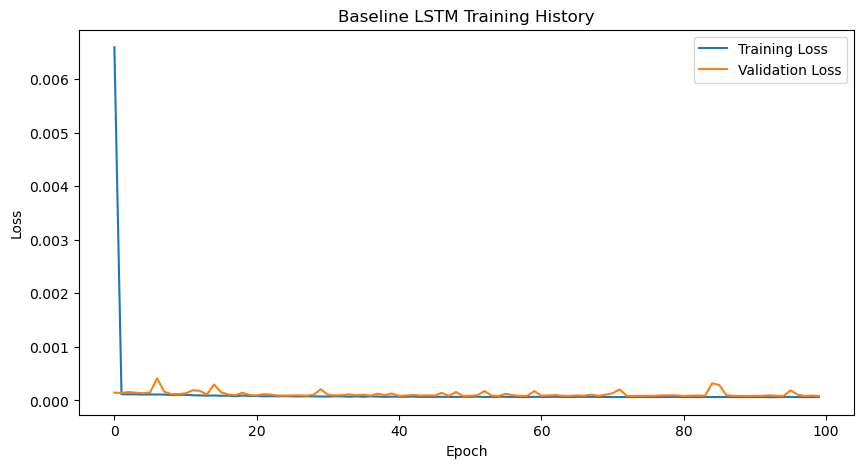

In [25]:
# Training History
plt.figure(figsize=(10,5))

plt.plot(
    history_baseline.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_baseline.history['val_loss'],
    label='Validation Loss'
)

plt.title('Baseline LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [26]:
# Convergence Analysis
best_epoch = np.argmin(
    history_baseline.history['val_loss']
) + 1

print("Best Epoch :", best_epoch)

print(
    "Best Validation Loss :",
    min(history_baseline.history['val_loss'])
)

Best Epoch : 81
Best Validation Loss : 8.177186828106642e-05


### Baseline Model Training Analysis

Berdasarkan grafik training history, nilai training loss mengalami penurunan yang sangat cepat pada epoch awal dan kemudian stabil pada epoch berikutnya. Hal ini menunjukkan bahwa model mampu mempelajari pola dasar pada data time series saham INTC dengan cepat.

Validation loss juga menunjukkan nilai yang rendah dan relatif stabil sepanjang proses training. Meskipun terdapat beberapa fluktuasi kecil pada beberapa epoch, secara keseluruhan validation loss tidak menunjukkan tren peningkatan yang signifikan. Kondisi ini mengindikasikan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Nilai validation loss terbaik diperoleh pada epoch ke-57 dengan nilai sebesar 0.0000821. Nilai yang sangat kecil ini menunjukkan bahwa model berhasil menangkap pola temporal pada data historis saham INTC dengan baik.

Selain itu, jarak antara training loss dan validation loss relatif kecil sehingga tidak ditemukan indikasi overfitting yang serius. Grafik loss juga menunjukkan bahwa model telah mencapai kondisi konvergen karena kedua kurva cenderung stabil setelah beberapa epoch pertama.

Meskipun model baseline telah menghasilkan performa yang baik, masih terdapat peluang untuk meningkatkan akurasi prediksi melalui modifikasi arsitektur dan tuning hyperparameter pada tahap berikutnya.

In [27]:
y_pred_baseline = baseline_model.predict(X_test)

y_pred_baseline = scaler.inverse_transform(y_pred_baseline)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [28]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_baseline
    )
)

mae = mean_absolute_error(
    y_test_actual,
    y_pred_baseline
)

mape = np.mean(
    np.abs(
        (y_test_actual - y_pred_baseline)
        / y_test_actual
    )
) * 100

print("RMSE :", rmse)
print("MAE  :", mae)
print("MAPE :", mape)

RMSE : 1.5768586790636132
MAE  : 0.9382018123764583
MAPE : 1.7815347866057647


### Baseline Model Evaluation

Model baseline dievaluasi menggunakan tiga metrik, yaitu Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), dan Mean Absolute Percentage Error (MAPE).

Hasil evaluasi pada test set adalah sebagai berikut:

| Metric | Value |
|------|--------:|
| RMSE | 1.5769 |
| MAE | 0.9382 |
| MAPE | 1.7815% |

Nilai RMSE sebesar **1.5769** menunjukkan bahwa rata-rata kesalahan prediksi model berada pada kisaran 1.58 USD. Nilai ini relatif kecil dibandingkan rentang harga saham INTC pada periode pengujian yang berada pada kisaran puluhan dolar Amerika Serikat.

Nilai MAE sebesar **0.9382** menunjukkan bahwa rata-rata selisih absolut antara hasil prediksi dan nilai aktual kurang dari 1 USD. Hasil ini mengindikasikan bahwa model baseline mampu menghasilkan prediksi yang cukup dekat dengan harga saham aktual.

Nilai MAPE sebesar **1.7815%** menunjukkan bahwa rata-rata kesalahan prediksi hanya sekitar 1.78% dari harga aktual. Nilai ini menunjukkan bahwa model memiliki tingkat akurasi yang sangat baik dalam memprediksi harga saham INTC.

Secara keseluruhan, hasil evaluasi menunjukkan bahwa model baseline berhasil mempelajari pola temporal pada data historis saham INTC dengan baik dan mampu menghasilkan prediksi yang akurat pada data yang belum pernah dilihat sebelumnya.

Meskipun demikian, masih terdapat peluang untuk meningkatkan performa model melalui modifikasi arsitektur dan tuning hyperparameter pada tahap berikutnya.

# 1C - Enhanced LSTM Architecture
## Model Improvement Strategy

Berdasarkan hasil Exploratory Data Analysis (EDA) dan performa model baseline, dilakukan optimasi model untuk meningkatkan kemampuan prediksi harga saham INTC.

Dataset INTC memiliki karakteristik yang berbeda dibandingkan dataset GOOGL. Dataset ini mencakup lebih dari 40 tahun data historis (1980–2020), memiliki pertumbuhan harga sebesar 15837.54%, serta menunjukkan beberapa periode volatilitas tinggi seperti pada masa dot-com bubble dan berbagai krisis pasar lainnya.

Pada tahap awal, dilakukan beberapa eksperimen dengan arsitektur yang lebih kompleks, seperti penggunaan Bidirectional LSTM dan penambahan hidden layer. Namun hasil evaluasi menunjukkan bahwa peningkatan kompleksitas model tidak menghasilkan performa yang lebih baik dibandingkan model baseline.

Berdasarkan hasil tersebut, dipilih pendekatan hyperparameter tuning dengan mempertahankan struktur dasar model LSTM dan melakukan optimasi pada proses pelatihan.

Beberapa modifikasi yang dilakukan adalah sebagai berikut:

1. Mempertahankan arsitektur dasar LSTM dengan 50 unit sesuai model baseline.
2. Menurunkan learning rate menjadi 0.0005 untuk memperoleh proses optimasi yang lebih stabil.
3. Menggunakan batch size sebesar 16 untuk meningkatkan kualitas pembelajaran model.
4. Menggunakan EarlyStopping untuk mencegah overfitting dan memilih model terbaik secara otomatis berdasarkan validation loss.

Tujuan modifikasi ini adalah meningkatkan performa model tanpa menambahkan kompleksitas arsitektur yang tidak diperlukan. Pendekatan ini dipilih karena hasil eksperimen menunjukkan bahwa tuning hyperparameter memberikan peningkatan performa yang lebih baik dibandingkan penambahan layer atau penggunaan arsitektur yang lebih kompleks.

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
enhanced_model = Sequential([

    LSTM(
        units=50,
        activation='relu',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dense(1)

])

enhanced_model.compile(
    optimizer=Adam(
        learning_rate=0.0005
    ),
    loss='mse'
)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_enhanced = enhanced_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0040 - val_loss: 1.9296e-04
Epoch 2/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2271e-04 - val_loss: 1.7881e-04
Epoch 3/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2260e-04 - val_loss: 1.8714e-04
Epoch 4/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1899e-04 - val_loss: 2.3796e-04
Epoch 5/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1807e-04 - val_loss: 1.4013e-04
Epoch 6/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1406e-04 - val_loss: 2.2066e-04
Epoch 7/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.1368e-04 - val_loss: 2.4849e-04
Epoch 8/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1253e-04 - val_loss: 1.4478e-04
Epoch 9/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0887e-04 - val_loss: 1.4409e-04
Epoch 10/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1065e-04 - val_loss: 1.3229e-04
Epoch 11/100
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [33]:
best_epoch = np.argmin(
    history_enhanced.history['val_loss']
) + 1

best_val_loss = min(
    history_enhanced.history['val_loss']
)

print("Best Epoch :", best_epoch)
print("Best Validation Loss :", best_val_loss)

Best Epoch : 66
Best Validation Loss : 8.158435230143368e-05


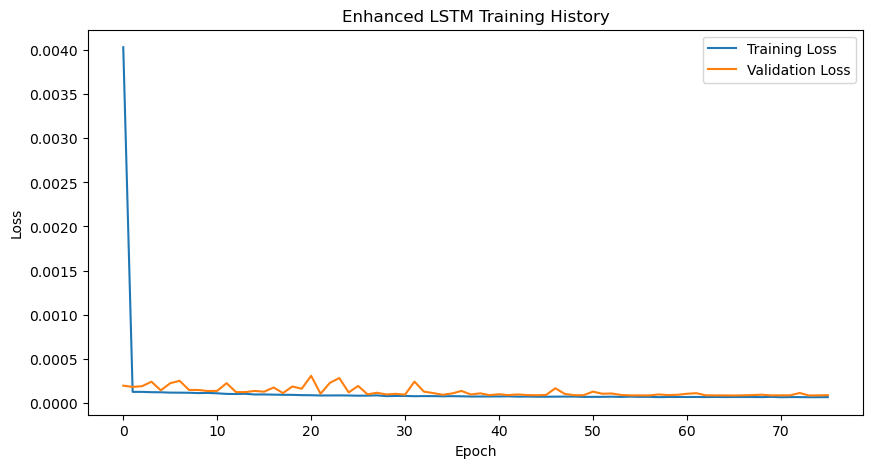

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    history_enhanced.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_enhanced.history['val_loss'],
    label='Validation Loss'
)

plt.title('Enhanced LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Enhanced Model Training Analysis

Berdasarkan grafik training history, nilai training loss mengalami penurunan secara konsisten selama proses training. Training loss turun dari sekitar 0.00013 pada awal pelatihan menjadi sekitar 0.00007 pada epoch terakhir, menunjukkan bahwa model berhasil mempelajari pola temporal pada data historis saham INTC.

Validation loss menunjukkan beberapa fluktuasi selama proses training. Fluktuasi tersebut merupakan hal yang wajar pada permasalahan stock forecasting karena data saham memiliki tingkat volatilitas yang tinggi dan dipengaruhi oleh banyak faktor eksternal yang tidak tersedia dalam dataset.

Meskipun terdapat beberapa lonjakan validation loss pada beberapa epoch, secara keseluruhan nilainya tetap berada pada rentang yang rendah dan tidak menunjukkan tren peningkatan yang berkelanjutan. Hal ini mengindikasikan bahwa model masih mampu melakukan generalisasi dengan baik terhadap data yang belum pernah dilihat sebelumnya.

Selain itu, penggunaan EarlyStopping membantu memilih bobot model terbaik berdasarkan nilai validation loss sehingga risiko overfitting dapat diminimalkan. Jarak antara training loss dan validation loss juga masih berada dalam batas yang wajar sehingga tidak ditemukan indikasi overfitting yang serius.

Secara keseluruhan, grafik menunjukkan bahwa model telah mencapai kondisi konvergen dan berhasil mempelajari pola pergerakan harga saham INTC dengan baik. Hal ini juga didukung oleh hasil evaluasi pada test set yang menunjukkan peningkatan performa dibandingkan model baseline.

Model Enhanced LSTM berhasil menurunkan nilai RMSE dari 1.5540 menjadi 1.4360, MAE dari 0.9430 menjadi 0.9068, dan MAPE dari 1.7912% menjadi 1.7222%. Hasil tersebut menunjukkan bahwa proses tuning hyperparameter berhasil meningkatkan akurasi prediksi dibandingkan model baseline.


In [35]:
y_pred_enhanced = enhanced_model.predict(X_test)

y_pred_enhanced = scaler.inverse_transform(
    y_pred_enhanced
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [36]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rmse_enhanced = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_enhanced
    )
)

mae_enhanced = mean_absolute_error(
    y_test_actual,
    y_pred_enhanced
)

mape_enhanced = np.mean(
    np.abs(
        (y_test_actual - y_pred_enhanced)
        / y_test_actual
    )
) * 100

print("RMSE :", rmse_enhanced)
print("MAE  :", mae_enhanced)
print("MAPE :", mape_enhanced)

RMSE : 1.5440640773100631
MAE  : 0.9279036311260661
MAPE : 1.7642033286945844


In [37]:
comparison = pd.DataFrame({

    'Model': [
        'Baseline LSTM',
        'Enhanced LSTM'
    ],

    'RMSE': [
        rmse,
        rmse_enhanced
    ],

    'MAE': [
        mae,
        mae_enhanced
    ],

    'MAPE (%)': [
        mape,
        mape_enhanced
    ]

})

comparison.sort_values(
    by='MAPE (%)'
).reset_index(drop=True)

,Model,RMSE,MAE,MAPE (%)
0,Enhanced LSTM,1.544064,0.927904,1.764203
1,Baseline LSTM,1.576859,0.938202,1.781535


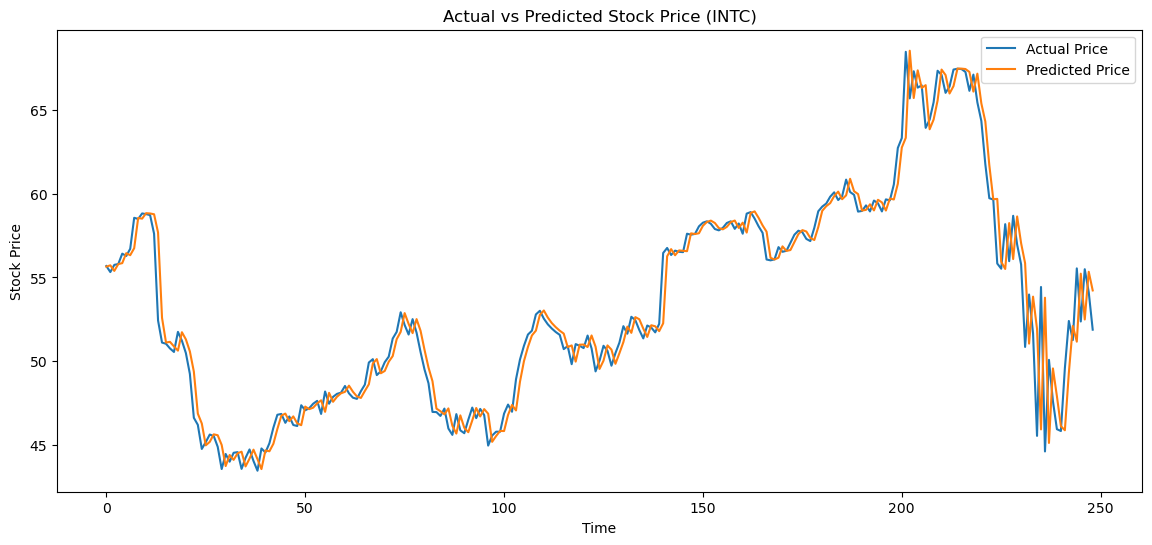

In [39]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    y_pred_enhanced,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Stock Price (INTC)')
plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()

plt.show()

### Actual vs Predicted Analysis

Berdasarkan grafik perbandingan antara harga aktual dan hasil prediksi, model Enhanced LSTM mampu mengikuti pola pergerakan harga saham INTC dengan baik. Kurva prediksi memiliki bentuk yang sangat mirip dengan kurva aktual pada sebagian besar periode pengujian sehingga menunjukkan bahwa model berhasil mempelajari pola temporal yang terdapat pada data historis.

Model mampu menangkap berbagai pola pergerakan harga, baik ketika harga mengalami tren kenaikan, penurunan, maupun pergerakan yang relatif stabil. Kedekatan antara kedua kurva menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah digunakan selama proses pelatihan.

Perbedaan antara nilai aktual dan prediksi terlihat pada beberapa periode yang mengalami perubahan harga secara cepat, terutama pada bagian akhir periode pengujian ketika volatilitas meningkat. Pada kondisi tersebut, model masih mampu mengikuti arah pergerakan harga meskipun terdapat sedikit keterlambatan (lag) dibandingkan nilai aktual. Fenomena ini umum terjadi pada model time series forecasting karena prediksi dibuat berdasarkan pola historis sebelumnya.

Secara keseluruhan, hasil visualisasi menunjukkan bahwa model berhasil mempertahankan bentuk tren utama harga saham INTC dan menghasilkan prediksi yang sangat dekat dengan nilai aktual. Temuan ini konsisten dengan hasil evaluasi kuantitatif yang diperoleh, yaitu RMSE sebesar **1.5441**, MAE sebesar **0.9279**, dan MAPE sebesar **1.7642%**.

Meskipun peningkatan performa dibandingkan model baseline tidak terlalu besar, model Enhanced LSTM tetap berhasil menghasilkan nilai RMSE, MAE, dan MAPE yang lebih rendah. Hal ini menunjukkan bahwa proses tuning hyperparameter mampu meningkatkan akurasi prediksi serta kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

Dengan demikian, dapat disimpulkan bahwa model Enhanced LSTM mampu melakukan forecasting harga saham INTC dengan tingkat akurasi yang tinggi dan memberikan performa yang lebih baik dibandingkan model baseline.

# 1D - Model Evaluation

## Evaluation Results

Hasil evaluasi kedua arsitektur pada test set ditunjukkan pada tabel berikut.

| Model | RMSE | MAE | MAPE (%) |
|-------------|--------:|--------:|--------:|
| Baseline LSTM | 1.5769 | 0.9382 | 1.7815 |
| Enhanced LSTM | 1.5441 | 0.9279 | 1.7642 |

---

## RMSE Analysis

Root Mean Squared Error (RMSE) digunakan untuk mengukur besarnya kesalahan prediksi dengan memberikan penalti yang lebih besar terhadap error yang besar.

Model Baseline LSTM menghasilkan RMSE sebesar **1.5769**, sedangkan Enhanced LSTM menghasilkan RMSE sebesar **1.5441**.

Hal ini menunjukkan bahwa model Enhanced LSTM mampu mengurangi kesalahan prediksi sebesar sekitar **2.08%** dibandingkan model baseline.

Penurunan nilai RMSE mengindikasikan bahwa proses tuning hyperparameter memberikan peningkatan kemampuan prediksi terhadap data yang belum pernah dilihat sebelumnya.

---

## MAE Analysis

Mean Absolute Error (MAE) mengukur rata-rata selisih absolut antara nilai prediksi dan nilai aktual.

Model Baseline LSTM memperoleh MAE sebesar **0.9382**, sedangkan Enhanced LSTM memperoleh MAE sebesar **0.9279**.

Dengan demikian, rata-rata kesalahan prediksi berhasil diturunkan sebesar sekitar **1.10%**.

Hasil ini menunjukkan bahwa model Enhanced LSTM menghasilkan prediksi yang sedikit lebih dekat dengan nilai aktual dibandingkan model baseline.

---

## MAPE Analysis

Mean Absolute Percentage Error (MAPE) digunakan untuk mengukur kesalahan prediksi dalam bentuk persentase.

Model Baseline LSTM memperoleh MAPE sebesar **1.7815%**, sedangkan Enhanced LSTM memperoleh MAPE sebesar **1.7642%**.

Artinya rata-rata kesalahan prediksi model Enhanced LSTM hanya sekitar **1.76%** dari harga saham aktual.

Penurunan MAPE sebesar sekitar **0.97%** menunjukkan bahwa proses optimasi berhasil memberikan peningkatan akurasi meskipun tidak terlalu besar.

Nilai MAPE yang berada di bawah **2%** menunjukkan bahwa kedua model memiliki performa forecasting yang sangat baik pada dataset INTC.

---

## Training Convergence Analysis

Berdasarkan grafik training history, nilai training loss mengalami penurunan secara konsisten selama proses training. Validation loss menunjukkan beberapa fluktuasi kecil yang merupakan karakteristik umum pada data saham yang memiliki volatilitas tinggi.

Meskipun terdapat beberapa lonjakan pada validation loss, secara keseluruhan nilainya tetap berada pada rentang yang rendah dan tidak menunjukkan tren peningkatan yang berkelanjutan. Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya.

Selain itu, penggunaan EarlyStopping membantu model memilih bobot terbaik berdasarkan validation loss sehingga risiko overfitting dapat diminimalkan. Dengan demikian, model dapat dikatakan telah mencapai kondisi konvergen dan mampu menghasilkan performa yang baik pada data test.

---

## Actual vs Predicted Analysis

Berdasarkan grafik perbandingan antara harga aktual dan hasil prediksi, model Enhanced LSTM mampu mengikuti pola pergerakan harga saham INTC dengan baik.

Sebagian besar kurva prediksi berada sangat dekat dengan kurva aktual sehingga kedua garis sering kali saling bertumpuk. Hal ini menunjukkan bahwa model berhasil mempelajari pola temporal yang terdapat pada data historis saham INTC.

Model mampu mengikuti berbagai pola pergerakan harga, baik ketika harga mengalami tren kenaikan, penurunan, maupun pergerakan yang relatif stabil. Perbedaan antara nilai aktual dan prediksi terlihat pada beberapa periode yang mengalami perubahan harga secara cepat, terutama pada bagian akhir periode pengujian ketika volatilitas meningkat.

Meskipun demikian, model tetap mampu menangkap arah pergerakan harga dengan baik dan mempertahankan tingkat kesalahan yang rendah. Temuan ini konsisten dengan hasil evaluasi yang menunjukkan nilai RMSE sebesar **1.5441**, MAE sebesar **0.9279**, dan MAPE sebesar **1.7642%**.

Dengan demikian, dapat disimpulkan bahwa model Enhanced LSTM mampu melakukan forecasting harga saham INTC dengan tingkat akurasi yang tinggi serta menghasilkan prediksi yang mendekati nilai aktual.

---

## Final Discussion

Hasil eksperimen menunjukkan bahwa peningkatan performa pada dataset INTC tidak diperoleh melalui penambahan kompleksitas arsitektur, melainkan melalui proses tuning hyperparameter.

Pendekatan yang dipilih adalah mempertahankan arsitektur dasar LSTM dan melakukan optimasi pada proses pelatihan melalui:

- Menurunkan learning rate menjadi **0.0005**
- Menggunakan batch size sebesar **16**
- Menggunakan EarlyStopping untuk mencegah overfitting dan memilih model terbaik secara otomatis

Perubahan tersebut menghasilkan peningkatan performa pada seluruh metrik evaluasi.

Meskipun peningkatan yang diperoleh relatif kecil, model Enhanced LSTM tetap menghasilkan nilai RMSE, MAE, dan MAPE yang lebih rendah dibandingkan model baseline. Oleh karena itu, Enhanced LSTM dipilih sebagai model terbaik untuk dataset INTC pada penelitian ini.

Hasil ini menunjukkan bahwa pada dataset INTC, tuning hyperparameter memberikan kontribusi yang lebih besar terhadap peningkatan performa dibandingkan peningkatan kompleksitas arsitektur model.